<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/Transformer_Book_Cover_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers
!pip install accelerate
!pip install sentence-transformers
!pip install diffusers
!pip install datasets
!pip install faiss-cpu
!pip install torch torchvision
!pip install pandas
!pip install scikit-learn
!pip install pillow

In [ ]:
#Input
 ↓
#Embedding
 ↓
#Positional Encoding
 ↓
#Encoder
 ↓
#Decoder
 ↓
#Output

In [2]:
#https://www.kaggle.com/datasets/jealousleopard/goodreadsbooks

In [3]:
import pandas as pd

data = pd.read_csv('/content/books.csv', on_bad_lines='skip')
data.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [4]:
df = data[['title','authors']]

In [5]:
df = df.dropna()

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

text = df.iloc[0]['title']

tokens = tokenizer.tokenize(text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
#I    Position 1
#love Position 2
#AI   Position 3

In [7]:
encoded = tokenizer(
    text,
    padding='max_length',
    truncation=True,
    max_length=32
)

print(encoded)

{'input_ids': [101, 4302, 10693, 1998, 1996, 2431, 1011, 2668, 3159, 1006, 4302, 10693, 1001, 1020, 1007, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [8]:
#EMBEDDINGS

from transformers import AutoModel

model = AutoModel.from_pretrained(
    "bert-base-uncased"
)

inputs = tokenizer(
    text,
    return_tensors="pt"
)

outputs = model(**inputs)

outputs.last_hidden_state.shape

torch.Size([1, 16, 768])

In [9]:
attentions = outputs.attentions

In [10]:
model.config.num_attention_heads

12

In [11]:
from transformers import pipeline

In [12]:
classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [13]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="gpt2"
)

Device set to use cpu


In [14]:
prompt = """
Write a fantasy book summary"""

result = generator(
    prompt,
    max_length=150
)

print(result[0]['generated_text'])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Write a fantasy book summary of your favorite characters.

Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fantasy book summary of your favorite characters. Write a fant

In [15]:
import transformers
print(transformers.__version__)

4.52.4


In [16]:
!pip uninstall -y transformers
!pip install transformers==4.52.4 sentencepiece accelerate -q

Found existing installation: transformers 4.52.4
Uninstalling transformers-4.52.4:
  Successfully uninstalled transformers-4.52.4


In [17]:
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="t5-small"
)

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [21]:
book_description = """
A young warrior discovers an ancient dragon kingdom hidden beneath
the mountains. As dark forces begin to rise, he must unite rival
clans and unlock forgotten magic to save the realm.
"""

summary = summarizer(
    book_description,
    max_length=50,
    min_length=15,
    do_sample=False
)

print(summary[0]['summary_text'])

Your max_length is set to 50, but your input_length is only 41. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=20)
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


a young warrior discovers an ancient dragon kingdom hidden beneath the mountains . he must unite rival clans and unlock forgotten magic to save the realm .


In [22]:
prompt = """
Generate a short book tagline:
"""

In [23]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(
'all-MiniLM-L6-v2'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
embeddings = embedder.encode(
df['title'].tolist()
)

In [25]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
dimension
)

index.add(
np.array(embeddings)
)

In [26]:
query = embedder.encode(
["Fantasy Dragon"]
)

D,I = index.search(
query,
5
)

print(I)

[[8980 5506 5429 8356 7481]]


In [27]:
from transformers import CLIPProcessor
from transformers import CLIPModel

In [28]:
model = CLIPModel.from_pretrained(
"openai/clip-vit-base-patch32"
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [29]:
from transformers import ViTModel

In [30]:
vit = ViTModel.from_pretrained(
'google/vit-base-patch16-224'
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
from diffusers import AutoPipelineForText2Image
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [32]:
pipe = AutoPipelineForText2Image.from_pretrained(
"stabilityai/sdxl-turbo",
torch_dtype=torch.float32
)

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [33]:
prompt = """
Epic fantasy novel cover,
ancient dragon kingdom,
cinematic lighting,
professional book cover,
high quality
"""

image = pipe(
prompt,
num_inference_steps=1
).images[0]

image.save(
"book_cover.png"
)

  0%|          | 0/1 [00:00<?, ?it/s]

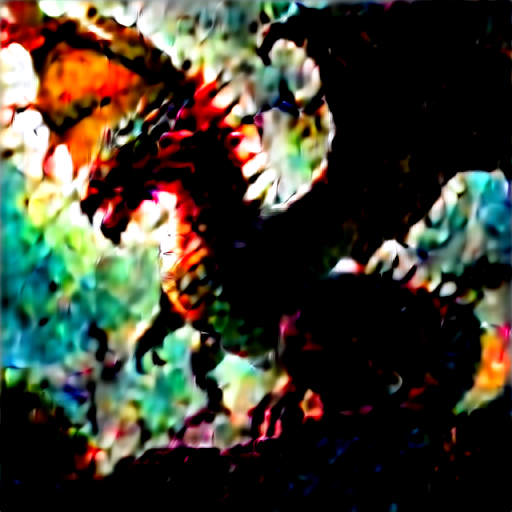

In [35]:
image